<a href="https://colab.research.google.com/github/di5han/AIFinalAssessment/blob/main/NewClass.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [71]:
# CELL 1: GLOBAL DEPENDENCIES & ENVIRONMENT SETUP
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

# Modeling, Preprocessing, and Validation Tools
from sklearn.model_selection import train_test_split, GridSearchCV
from sklearn.preprocessing import StandardScaler
from sklearn.feature_selection import RFE

# Classifiers (Task 2 & Task 3 Requirements)
from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier
from sklearn.neural_network import MLPClassifier

# Evaluation Metrics
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score

# Apply cohesive styling for high-quality figures
sns.set_theme(style="whitegrid")
plt.rcParams['figure.figsize'] = (10, 6)
print("Cell 1 complete: Advanced data science dependencies loaded successfully!")

Cell 1 complete: Advanced data science dependencies loaded successfully!


In [72]:
# CELL 2: DATA LOADING & INITIAL STRUCTURAL INSPECTION
# Load the dataset verbatim from instructions
filepath_class = "Healthcare Risk Factors Dataset.csv"
df_class = pd.read_csv("/content/drive/MyDrive/AIAssignment/Healthcare Risk Factors Dataset.csv")

print("=== RAW DATASET STRUCTURE ===")
print(f"Dimensions: {df_class.shape[0]} rows, {df_class.shape[1]} columns\n")
print("=== VARIABLE TYPE INVENTORY ===")
df_class.info()

print("\n=== SYSTEMATIC MISSING VALUE ASSESSMENT ===")
missing_counts = df_class.isnull().sum()
print(missing_counts[missing_counts > 0])

=== RAW DATASET STRUCTURE ===
Dimensions: 30000 rows, 20 columns

=== VARIABLE TYPE INVENTORY ===
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 30000 entries, 0 to 29999
Data columns (total 20 columns):
 #   Column             Non-Null Count  Dtype  
---  ------             --------------  -----  
 0   Age                25500 non-null  float64
 1   Gender             25500 non-null  object 
 2   Medical Condition  25500 non-null  object 
 3   Glucose            25500 non-null  float64
 4   Blood Pressure     25500 non-null  float64
 5   BMI                30000 non-null  float64
 6   Oxygen Saturation  30000 non-null  float64
 7   LengthOfStay       30000 non-null  int64  
 8   Cholesterol        30000 non-null  float64
 9   Triglycerides      30000 non-null  float64
 10  HbA1c              30000 non-null  float64
 11  Smoking            30000 non-null  int64  
 12  Alcohol            30000 non-null  int64  
 13  Physical Activity  30000 non-null  float64
 14  Diet Score         3

In [73]:
# CELL 3: DATA CLEANING, BIOMARKER IMPUTATION, & VARIABLE SELECTION
# 1. Strip high-cardinality metadata and arbitrary tracking noise
clean_class = df_class.drop(columns=['random_notes', 'noise_col', 'Gender', 'Medical Condition'], errors='ignore')

# 2. Strategic Imputation: Treat missing values with aggregate parameters to preserve statistical power
clean_class['Age'] = clean_class['Age'].fillna(clean_class['Age'].median())
clean_class['Glucose'] = clean_class['Glucose'].fillna(clean_class['Glucose'].mean())
clean_class['Blood Pressure'] = clean_class['Blood Pressure'].fillna(clean_class['Blood Pressure'].mean())

# 3. Standardize analytical boundaries
numerical_features_class = [
    'Age', 'Glucose', 'Blood Pressure', 'BMI', 'Oxygen Saturation',
    'Cholesterol', 'Triglycerides', 'HbA1c', 'Physical Activity',
    'Stress Level', 'Sleep Hours', 'Alcohol', 'Diet Score', 'Family History'
]
target_class = 'Smoking'

final_class_data = clean_class[numerical_features_class + [target_class]].dropna()
print(f"Cleaned dataset dimensions for machine learning pipeline: {final_class_data.shape}")

# Calculate missing value sum explicitly to prevent environment environment scoping issues
final_data_nulls = final_class_data.isnull().sum().sum()
print(f"Remaining structural missing values: {final_data_nulls}")

Cleaned dataset dimensions for machine learning pipeline: (30000, 15)
Remaining structural missing values: 0


/tmp/ipykernel_951/2121033085.py:4: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.countplot(data=final_class_data, x=target_class, palette="Set2")


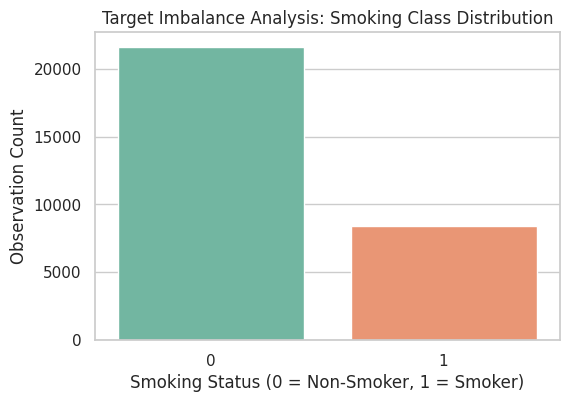

=== REVENUE DISTRIBUTION METRICS ===
Non-Smokers (Class 0): 72.02%
Smokers (Class 1):     27.98%



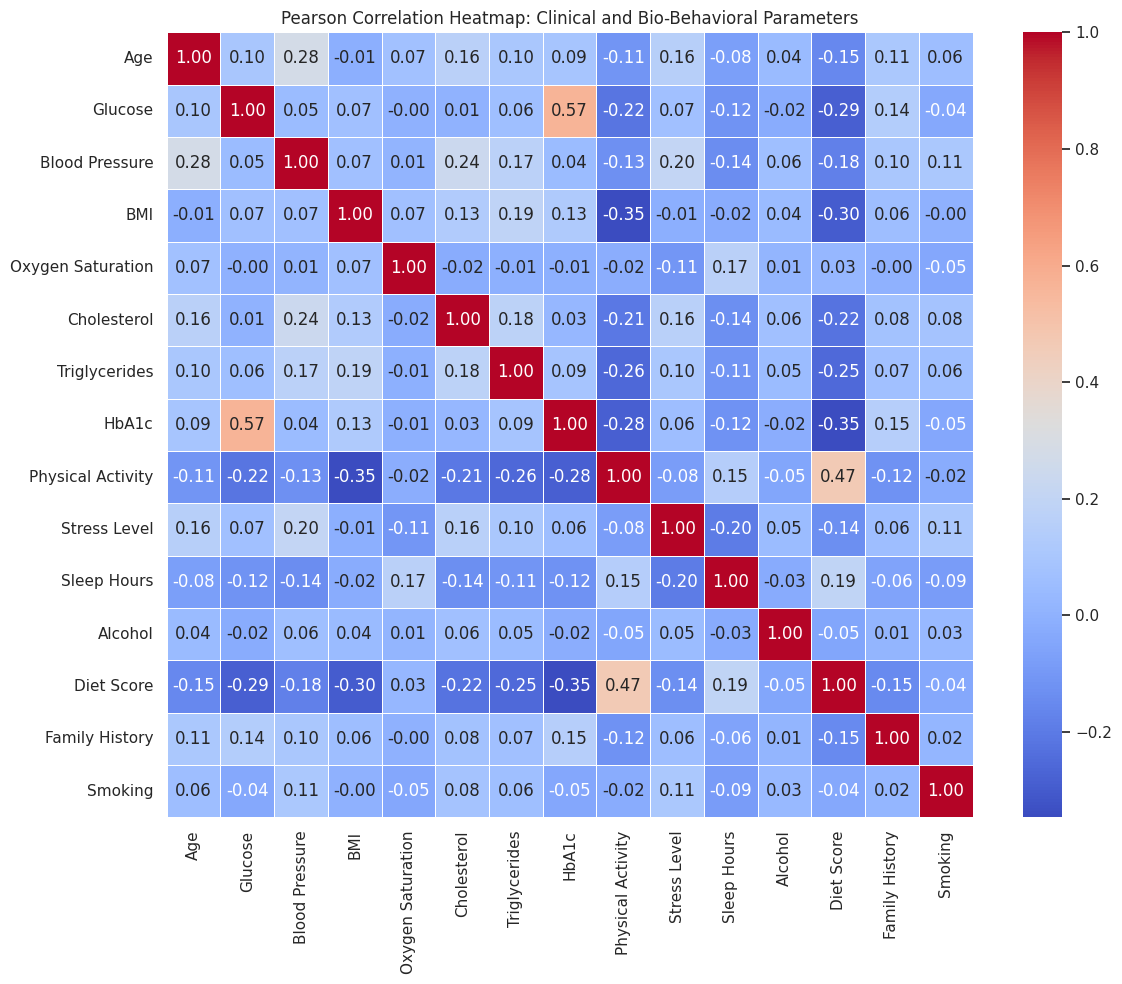

In [74]:
# CELL 4: EDA - CLASS PROFILES AND ATTRIBUTE INTERACTIONS
# Visualization 1: Target Class Balance Evaluation
plt.figure(figsize=(6, 4))
sns.countplot(data=final_class_data, x=target_class, palette="Set2")
plt.title("Target Imbalance Analysis: Smoking Class Distribution")
plt.xlabel("Smoking Status (0 = Non-Smoker, 1 = Smoker)")
plt.ylabel("Observation Count")
plt.savefig("classification_target_dist.png", dpi=300)
plt.show()

# Quantify base frequencies
class_ratios = final_class_data[target_class].value_counts(normalize=True) * 100
print("=== REVENUE DISTRIBUTION METRICS ===")
print(f"Non-Smokers (Class 0): {class_ratios[0]:.2f}%")
print(f"Smokers (Class 1):     {class_ratios[1]:.2f}%\n")

# Visualization 2: Pearson Matrix Correlation Heatmap
plt.figure(figsize=(12, 10))
sns.heatmap(final_class_data.corr(), annot=True, fmt=".2f", cmap="coolwarm", linewidths=0.5)
plt.title("Pearson Correlation Heatmap: Clinical and Bio-Behavioral Parameters")
plt.tight_layout()
plt.savefig("classification_heatmap.png", dpi=300)
plt.show()

In [75]:
# CELL 5: DATA SPLITTING & COHENSIVE STANDARDIZATION
X_c = final_class_data[numerical_features_class]
y_c = final_class_data[target_class]

# Stratify=y_c guarantees that the 72:28 imbalance split is precisely replicated in train and test splits
X_train_c, X_test_c, y_train_c, y_test_c = train_test_split(
    X_c, y_c, test_size=0.2, random_state=42, stratify=y_c
)

# Fit scaler strictly on the training partition to block any structural data leakage
scaler_c = StandardScaler()
X_train_c_scaled = scaler_c.fit_transform(X_train_c)
X_test_c_scaled = scaler_c.transform(X_test_c)

print(f"Training partition scaled dimensions: {X_train_c_scaled.shape}")
print(f"Testing partition scaled dimensions:  {X_test_c_scaled.shape}")

Training partition scaled dimensions: (24000, 14)
Testing partition scaled dimensions:  (6000, 14)


In [76]:
# CELL 6: NEURAL NETWORK ARCHITECTURE IMPLEMENTATION & EVALUATION
print("=== INITIALIZING NEURAL NETWORK TRAINING ===")

# Instantiate Multi-Layer Perceptron Classifier with early stopping to bound regularization
mlp_classifier = MLPClassifier(
    hidden_layer_sizes=(64, 32),
    activation='relu',
    solver='adam',
    max_iter=300,
    early_stopping=True,
    validation_fraction=0.1,
    random_state=42
)

mlp_classifier.fit(X_train_c_scaled, y_train_c)

# Generate train/test inferences to verify optimization safety
mlp_train_preds = mlp_classifier.predict(X_train_c_scaled)
mlp_test_preds = mlp_classifier.predict(X_test_c_scaled)

print("\n--- Neural Network Training Metrics ---")
print(f"Train Accuracy: {accuracy_score(y_train_c, mlp_train_preds):.4f}")
print(f"Train F1-Score: {f1_score(y_train_c, mlp_train_preds):.4f}")

print("\n--- Neural Network Testing Metrics ---")
print(f"Test Accuracy:  {accuracy_score(y_test_c, mlp_test_preds):.4f}")
print(f"Test Precision: {precision_score(y_test_c, mlp_test_preds, zero_division=0):.4f}")
print(f"Test Recall:    {recall_score(y_test_c, mlp_test_preds):.4f}")
print(f"Test F1-Score:  {f1_score(y_test_c, mlp_test_preds):.4f}")

=== INITIALIZING NEURAL NETWORK TRAINING ===

--- Neural Network Training Metrics ---
Train Accuracy: 0.7201
Train F1-Score: 0.0261

--- Neural Network Testing Metrics ---
Test Accuracy:  0.7172
Test Precision: 0.3200
Test Recall:    0.0095
Test F1-Score:  0.0185


In [77]:
# CELL 7: BUILD PRIMARY CLASSICAL MODELS (BASELINE EVALUATIONS)
print("=== STRUCTURING CLASSICAL DISCRIMINATIVE BASELINES ===")

# Model A: Parametric baseline
base_lr = LogisticRegression(random_state=42, max_iter=1000)
base_lr.fit(X_train_c_scaled, y_train_c)
preds_lr_base = base_lr.predict(X_test_c_scaled)

# Model B: Ensemble non-parametric baseline
base_rf = RandomForestClassifier(random_state=42, n_estimators=100)
base_rf.fit(X_train_c_scaled, y_train_c)
preds_rf_base = base_rf.predict(X_test_c_scaled)

print(f"✔ Baseline Logistic Regression Test F1: {f1_score(y_test_c, preds_lr_base):.4f}")
print(f"✔ Baseline Random Forest Test F1:       {f1_score(y_test_c, preds_rf_base):.4f}")

=== STRUCTURING CLASSICAL DISCRIMINATIVE BASELINES ===
✔ Baseline Logistic Regression Test F1: 0.0151
✔ Baseline Random Forest Test F1:       0.0718


In [78]:
# CELL 8: HYPERPARAMETER OPTIMIZATION (GRID SEARCH CV)
print("=== RUNNING PARALLELIZED EXHAUSTIVE EXPONENTIAL TUNING ===")

# Hyperparameter optimization grid for Model A
grid_space_lr = {'C': [0.01, 0.1, 1.0, 10.0], 'penalty': ['l2']}
cv_lr = GridSearchCV(LogisticRegression(random_state=42, max_iter=1000), grid_space_lr, cv=5, scoring='f1', n_jobs=-1)
cv_lr.fit(X_train_c_scaled, y_train_c)

# Hyperparameter optimization grid for Model B
grid_space_rf = {'n_estimators': [50, 100], 'max_depth': [5, 10, None]}
cv_rf = GridSearchCV(RandomForestClassifier(random_state=42), grid_space_rf, cv=5, scoring='f1', n_jobs=-1)
cv_rf.fit(X_train_c_scaled, y_train_c)

print("\n--- Hyperparameter Refinement Results ---")
print(f"Optimal LogReg Settings:   {cv_lr.best_params_}")
print(f"Best LogReg CV F1-Score:   {cv_lr.best_score_:.4f}")
print(f"Optimal Random Forest Settings: {cv_rf.best_params_}")
print(f"Best RandomForest CV F1:   {cv_rf.best_score_:.4f}")

=== RUNNING PARALLELIZED EXHAUSTIVE EXPONENTIAL TUNING ===

--- Hyperparameter Refinement Results ---
Optimal LogReg Settings:   {'C': 0.1, 'penalty': 'l2'}
Best LogReg CV F1-Score:   0.0260
Optimal Random Forest Settings: {'max_depth': None, 'n_estimators': 50}
Best RandomForest CV F1:   0.1023


In [79]:
# CELL 9: WRAPPER FEATURE SELECTION THROUGH RFE
print("=== CALCULATING RECURSIVE FEATURE ELIMINATION MATRIX ===")

# Retain top 6 primary risk features
selected_features_target = 6

rfe_selector_lr = RFE(estimator=LogisticRegression(random_state=42), n_features_to_select=selected_features_target)
rfe_selector_lr.fit(X_train_c_scaled, y_train_c)

rfe_selector_rf = RFE(estimator=RandomForestClassifier(random_state=42), n_features_to_select=selected_features_target)
rfe_selector_rf.fit(X_train_c_scaled, y_train_c)

rfe_features_lr = [numerical_features_class[i] for i in range(len(numerical_features_class)) if rfe_selector_lr.support_[i]]
rfe_features_rf = [numerical_features_class[i] for i in range(len(numerical_features_class)) if rfe_selector_rf.support_[i]]

print(f"✔ Isolated Features for Logistic Regression: {rfe_features_lr}")
print(f"✔ Isolated Features for Random Forest:       {rfe_features_rf}")

=== CALCULATING RECURSIVE FEATURE ELIMINATION MATRIX ===
✔ Isolated Features for Logistic Regression: ['Glucose', 'Blood Pressure', 'Cholesterol', 'HbA1c', 'Stress Level', 'Sleep Hours']
✔ Isolated Features for Random Forest:       ['BMI', 'Cholesterol', 'Triglycerides', 'HbA1c', 'Stress Level', 'Diet Score']


In [80]:
# CELL 10: FINAL SYSTEM REBUILD & REPORT GENERATION (TABLE 4)
print("=== ASSEMBLING OPTIMAL FINAL CONSTRAINED MODELS ===")

# Isolate feature matrices based on respective optimization indices
X_tr_lr = pd.DataFrame(X_train_c_scaled, columns=numerical_features_class)[rfe_features_lr]
X_ts_lr = pd.DataFrame(X_test_c_scaled, columns=numerical_features_class)[rfe_features_lr]

X_tr_rf = pd.DataFrame(X_train_c_scaled, columns=numerical_features_class)[rfe_features_rf]
X_ts_rf = pd.DataFrame(X_test_c_scaled, columns=numerical_features_class)[rfe_features_rf]

# Rebuild Model A
final_lr_model = LogisticRegression(random_state=42, max_iter=1000, **cv_lr.best_params_)
final_lr_model.fit(X_tr_lr, y_train_c)
final_preds_lr = final_lr_model.predict(X_ts_lr)

# Rebuild Model B
final_rf_model = RandomForestClassifier(random_state=42, **cv_rf.best_params_)
final_rf_model.fit(X_tr_rf, y_train_c)
final_preds_rf = final_rf_model.predict(X_ts_rf)

# Compile performance measurements
classification_report_summary = [
    {
        "Model": "Model A (Optimized LogReg)",
        "Features": f"Selected ({len(rfe_features_lr)})",
        "CV Score": f"{cv_lr.best_score_:.2f}",
        "Accuracy": f"{accuracy_score(y_test_c, final_preds_lr):.2f}",
        "Precision": f"{precision_score(y_test_c, final_preds_lr, zero_division=0):.2f}",
        "Recall": f"{recall_score(y_test_c, final_preds_lr):.2f}",
        "F1-Score": f"{f1_score(y_test_c, final_preds_lr):.2f}"
    },
    {
        "Model": "Model B (Optimized RandomForest)",
        "Features": f"Selected ({len(rfe_features_rf)})",
        "CV Score": f"{cv_rf.best_score_:.2f}",
        "Accuracy": f"{accuracy_score(y_test_c, final_preds_rf):.2f}",
        "Precision": f"{precision_score(y_test_c, final_preds_rf, zero_division=0):.2f}",
        "Recall": f"{recall_score(y_test_c, final_preds_rf):.2f}",
        "F1-Score": f"{f1_score(y_test_c, final_preds_rf):.2f}"
    }
]

# Display final output table formatted precisely to the template specifications
table_four_df = pd.DataFrame(classification_report_summary)
print("\n" + "="*85)
print("             TABLE 4: COMPARISON OF FINAL CLASSIFICATION MODELS")
print("="*85)
print(table_four_df.to_string(index=False))
print("="*85)

=== ASSEMBLING OPTIMAL FINAL CONSTRAINED MODELS ===

             TABLE 4: COMPARISON OF FINAL CLASSIFICATION MODELS
                           Model     Features CV Score Accuracy Precision Recall F1-Score
      Model A (Optimized LogReg) Selected (6)     0.03     0.72      0.29   0.01     0.01
Model B (Optimized RandomForest) Selected (6)     0.10     0.71      0.36   0.06     0.11
